# Phase 3 — Iteration 1: MLP Decoder vs MWPM Baseline

**Project:** surface-decoder-ml  
**Phase:** 3 (Modelling & Evaluation), Iteration 1 of the AMD Project Methodology  
**Author:** Abdullah Tarakji  
**Goal:** Establish the MWPM baseline and train a first neural decoder (an MLP) on the distance-3 rotated surface code, then compare their logical error rates on identical test data — and report that comparison *honestly*, with the right paired statistics.

---

### What this notebook does

1. **Load** the train/validation/test splits produced in Phase 2.
2. **MWPM baseline** — run PyMatching on the test set. This is the reference to beat.
3. **Train an MLP** — a small feed-forward network, across several random seeds, with early stopping on the validation set.
4. **Compare** — MLP vs MWPM logical error rate on the *same* test shots, using a **paired** significance test (McNemar), not overlapping marginal confidence intervals.

### What we can and cannot conclude at d=3

MWPM is a *minimum-weight* matching decoder. At distance 3 it is **near-optimal but not optimal**: because it minimises matching weight rather than error *likelihood*, it ignores **degeneracy** (many distinct physical errors producing the same logical effect). A maximum-likelihood decoder — which a sufficiently trained neural network can approximate — can therefore *beat* MWPM even at d=3, though only by a small margin. So a neural win at d=3 is not impossible; it is just small and hard to measure.

And measurement is the catch. At d=3, p=10⁻³, both decoders fail on only a tiny fraction of shots, and they disagree on only a few dozen of the 100,000 test shots. With so few **discordant** shots, a paired significance test has very little power. The honest framing for this iteration is therefore:

> **Report point estimates, a paired confidence interval, and a McNemar p-value — and treat a non-significant result as "no difference *detected* at this sample size" (an underpowered, inconclusive comparison), NOT as proof the two decoders are equivalent.**

A sharp, well-powered verdict needs far more logical-error events — more shots (10⁷–10⁸) or a higher physical error rate — which is the job of the threshold sweep in Iteration 2.

## Setup

In [23]:
import sys
import math
from pathlib import Path

# Make data_generation.py importable from notebooks/
ROOT = Path.cwd()
if not (ROOT / 'data_generation.py').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import torch
import torch.nn as nn
import pytorch_lightning as pl
from torch.utils.data import DataLoader, TensorDataset
import pymatching
import stim

from data_generation import generate_dataset, get_circuit

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
torch.set_float32_matmul_precision('high')  # use the RTX 5080's Tensor Cores

# A global seed makes the data loaders / MWPM path reproducible. Each MLP run later
# RE-seeds inside the training loop (Part 3) so the multiple seeds genuinely differ.
pl.seed_everything(42, workers=True)

# Record the full stack in the saved output, so the reported numbers carry their provenance.
print('python    :', sys.version.split()[0])
print('numpy     :', np.__version__)
print('torch     :', torch.__version__)
print('lightning :', pl.__version__)
print('stim      :', stim.__version__)
print('pymatching:', pymatching.__version__)
print('sklearn   :', sklearn.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU       :', torch.cuda.get_device_name(0))

Seed set to 42


python    : 3.11.14
numpy     : 2.3.5
torch     : 2.10.0+cu128
lightning : 2.6.1
stim      : 1.15.0
pymatching: 2.3.1
sklearn   : 1.8.0
CUDA available: True
GPU       : NVIDIA GeForce RTX 5080


---
# Part 1: Load the Phase 2 Splits

Phase 2 saved a stratified 80/10/10 split of the distance-3, 3-round, p=10⁻³ dataset. We load those splits directly so this notebook uses exactly the same data partition. We also rebuild the circuit's detector error model (DEM), which PyMatching needs for the MWPM baseline.

In [24]:
# Load the splits saved in Phase 2
split_path = ROOT / 'data_cache' / 'splits_d3_r3_p1e-03_n1000000_s42.npz'

if split_path.exists():
    data = np.load(split_path)
    X_train, y_train = data['X_train'], data['y_train']
    X_val,   y_val   = data['X_val'],   data['y_val']
    X_test,  y_test  = data['X_test'],  data['y_test']
    print('Loaded splits from Phase 2 cache.')
else:
    # Fallback: regenerate and split here if the Phase 2 cache is missing.
    # Both decoders use whatever X_test this produces, so the *paired* comparison stays
    # valid; but stratified-split internals are not guaranteed stable across sklearn
    # versions, so the exact shots (and therefore the exact error counts) may differ
    # from the committed Phase 2 run. The asserts below catch gross drift.
    print('Phase 2 split cache not found; regenerating (may not reproduce exact counts)...')
    from sklearn.model_selection import train_test_split
    X, y, _ = generate_dataset(distance=3, rounds=3, noise_p=1e-3,
                               n_shots=1_000_000, seed=42)
    X_tmp, X_test, y_tmp, y_test = train_test_split(
        X, y, test_size=0.10, stratify=y, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(
        X_tmp, y_tmp, test_size=1/9, stratify=y_tmp, random_state=42)

# Fail loud if the split is not the documented Phase 2 partition. The whole MLP-vs-MWPM
# comparison is paired on these exact shots, so a silently different split would be a bug.
assert len(y_test) == 100_000, f'expected 100,000 test shots, got {len(y_test):,}'
assert len(y_val) == 100_000, f'expected 100,000 val shots, got {len(y_val):,}'
assert int(y_test.sum()) == 2246, f'expected 2,246 test flips (Phase 2), got {int(y_test.sum()):,}'
assert int(y_val.sum()) == 2246, f'expected 2,246 val flips (Phase 2), got {int(y_val.sum()):,}'

n_test = len(y_test)
for name, Xs, ys in [('train', X_train, y_train),
                     ('val',   X_val,   y_val),
                     ('test',  X_test,  y_test)]:
    print(f'{name:6s} | shots: {len(ys):7d} | flips: {int(ys.sum()):6d} | rate: {ys.mean():.4%}')

Loaded splits from Phase 2 cache.
train  | shots:  800000 | flips:  17972 | rate: 2.2465%
val    | shots:  100000 | flips:   2246 | rate: 2.2460%
test   | shots:  100000 | flips:   2246 | rate: 2.2460%


In [25]:
# Rebuild the detector error model for the MWPM baseline.
# The DEM comes from the CIRCUIT, not the data, so MWPM never sees any labels.
# Build it straight from the circuit (no sampling, no junk n=1 cache file). This is
# byte-identical to the `dem` that generate_dataset returns for the same parameters.
dem = get_circuit(distance=3, rounds=3, noise_p=1e-3).detector_error_model(decompose_errors=True)

# Guard against parameter drift: the DEM's detector count must match the cached split's
# feature width, or MWPM would be decoding syndromes from a different circuit.
assert X_test.shape[1] == dem.num_detectors, (
    f'detector mismatch: X has {X_test.shape[1]} columns, DEM has {dem.num_detectors}')

print('DEM error mechanisms:', dem.num_errors)
print('Detectors per shot   :', dem.num_detectors)

DEM error mechanisms: 286
Detectors per shot   : 24


---
# Part 2: MWPM Baseline (PyMatching)

Minimum-Weight Perfect Matching is the standard surface-code decoder. PyMatching builds a matching graph directly from the detector error model and decodes each shot by finding the lowest-weight set of error chains consistent with the observed syndrome. It then predicts whether the logical observable was flipped.

This is a **non-learned** decoder — it uses the known error model, not training data — so it is the fair, strong baseline that the neural network must match or beat.

In [26]:
# Build the MWPM decoder from the detector error model
matching = pymatching.Matching.from_detector_error_model(dem)
assert matching.num_detectors == dem.num_detectors == X_test.shape[1]

# Decode the entire test set in one batch call. mwpm_pred is (n_test,) bool,
# index-aligned to X_test / y_test.
mwpm_pred = np.asarray(matching.decode_batch(X_test)).ravel().astype(bool)

# The paired comparison later assumes mwpm_pred is fixed/deterministic. Min-weight
# matching can in principle break weight ties arbitrarily, so confirm a second decode
# is identical before we rely on it.
assert np.array_equal(np.asarray(matching.decode_batch(X_test)).ravel().astype(bool), mwpm_pred), \
    'MWPM predictions are not reproducible across calls'

# Logical error rate = fraction of shots where MWPM's prediction != truth
mwpm_errors = int(np.sum(mwpm_pred != y_test))
mwpm_ler = mwpm_errors / n_test

print('MWPM logical errors    : {:,} / {:,}'.format(mwpm_errors, n_test))
print('MWPM logical error rate: {:.4%}'.format(mwpm_ler))

MWPM logical errors    : 81 / 100,000
MWPM logical error rate: 0.0810%


### Interpretation — MWPM Baseline

This logical error rate is the reference for the rest of the project. Note it is far **lower** than the ~2.25% logical-flip rate of the dataset itself (Phase 2): that rate is the fraction of shots in which a logical error *occurred in the data*, whereas this is the fraction in which the decoder *failed to correct it*. Equivalently, a do-nothing decoder that always predicts "no flip" would have a logical error rate equal to the positive rate (~2.25%); MWPM is far below that, so it is genuinely decoding. We make that trivial baseline explicit in Part 4. The MLP below is judged against this MWPM number, on the same test shots.

---
# Part 3: Train the MLP Decoder

The MLP treats the 24 detector bits as a flat feature vector and predicts a single value: the probability that a logical error occurred. This is the simplest possible neural decoder and follows the approach of Varsamopoulos, Criger & Bertels (2018).

## 3.1 Prepare PyTorch data loaders

Cast the boolean arrays to `float32` (PyTorch works with floats) and wrap them in `DataLoader`s. No scaling is applied — the features are already binary, as established in Phase 2.

In [27]:
def make_loader(X, y, batch_size=4096, shuffle=False, generator=None):
    X_t = torch.from_numpy(X.astype(np.float32))
    y_t = torch.from_numpy(y.astype(np.float32))
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, generator=generator,
                      num_workers=0, pin_memory=torch.cuda.is_available())

# Validation and test loaders are fixed (no shuffling). The TRAIN loader is built
# per-seed inside the training loop so each run shuffles differently.
val_loader  = make_loader(X_val,  y_val)
test_loader = make_loader(X_test, y_test)

n_features = X_train.shape[1]
print(f'Input features: {n_features}')
print(f'Train shots   : {len(y_train):,}  (batches of 4096 -> {math.ceil(len(y_train)/4096)} per epoch)')

Input features: 24
Train shots   : 800,000  (batches of 4096 -> 196 per epoch)


## 3.2 Define the MLP

A `LightningModule` with three hidden layers (256 units each), ReLU activations, dropout for regularization, and a single logit output. The loss is binary cross-entropy (`BCEWithLogitsLoss`, which combines the sigmoid and the loss for numerical stability).

Two deliberate choices:

- **Model selection uses `val_loss`, not `val_ler`.** Validation logical-error-rate counts only ~50 errors out of 100,000 val shots, so it jumps around by single-shot binomial noise (≈ ±√50 ≈ ±7 errors). With early stopping's default `min_delta=0`, every one-shot wiggle would look like an "improvement" and the saved checkpoint would latch onto a noise minimum. `val_loss` is a *smooth* signal that uses every shot's probability, so it selects a genuinely better model. We still **report** `val_ler` as a diagnostic.
- **The validation LER is computed exactly**, by accumulating error and shot counts across all validation batches and dividing once at epoch end — rather than averaging per-batch rates (which would mis-weight the smaller final batch). PyTorch Lightning's `self.log` already does the right thing here via batch-size inference, so this is a robustness / self-documenting choice, not a bug fix.

In [28]:
class MLPDecoder(pl.LightningModule):
    def __init__(self, n_features, hidden=256, depth=3, dropout=0.2, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        layers = []
        in_dim = n_features
        for _ in range(depth):
            layers += [nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = hidden
        layers += [nn.Linear(in_dim, 1)]  # single logit output
        self.net = nn.Sequential(*layers)
        self.loss_fn = nn.BCEWithLogitsLoss()
        # Accumulators for an EXACT validation LER (reset each epoch).
        self._val_err = 0
        self._val_tot = 0

    def forward(self, x):
        return self.net(x).squeeze(-1)  # raw logits

    def training_step(self, batch, _):
        x, y = batch
        loss = self.loss_fn(self(x), y)
        self.log('train_loss', loss, prog_bar=True)
        return loss

    def on_validation_epoch_start(self):
        self._val_err = 0
        self._val_tot = 0

    def validation_step(self, batch, _):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        # val_loss is the model-selection signal (smooth, uses every shot).
        self.log('val_loss', loss, prog_bar=True)
        # Accumulate raw counts for an exact epoch-level LER (decision threshold 0.5;
        # 0.5 is Bayes-optimal for a calibrated probability under symmetric 0/1 cost).
        preds = (torch.sigmoid(logits) > 0.5)
        self._val_err += int((preds != (y > 0.5)).sum().item())
        self._val_tot += int(y.numel())

    def on_validation_epoch_end(self):
        if self._val_tot:  # skip the sanity-check pass Lightning runs before training
            val_ler = self._val_err / self._val_tot
            self.log('val_ler', val_ler, prog_bar=True)  # reported diagnostic only

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

print(MLPDecoder(n_features=n_features))

MLPDecoder(
  (net): Sequential(
    (0): Linear(in_features=24, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=256, out_features=1, bias=True)
  )
  (loss_fn): BCEWithLogitsLoss()
)


## 3.3 Train — across several random seeds

A single training run is one random draw: weight initialisation, dropout masks and shuffling all depend on the seed, and the resulting test LER varies from run to run. Since the whole comparison turns on a difference of only a few errors, **a single run would give a falsely precise answer** — the run-to-run spread is plausibly larger than the MLP-vs-MWPM gap.

So we train the MLP on **several seeds**. Each run trains for up to 40 epochs with early stopping on `val_loss` (patience 6) and restores its best checkpoint. We then look at two *different* things, which must not be conflated:

1. The **spread** of test LER across seeds — a descriptive measure of training-init variance (Part 4).
2. A **single** model — the one with the best validation loss — which feeds the one paired significance test against MWPM. Selecting on validation (disjoint from test) keeps that test honest.

`deterministic='warn'` makes each run reproducible where CUDA kernels allow (and warns rather than crashing where they don't). On an RTX 5080 each seed takes well under a minute at d=3.

In [29]:
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

SEEDS = [42, 0, 1, 2, 3]                       # multiple random inits -> training-variance spread
CKPT_ROOT = ROOT / 'checkpoints' / 'iter1_mlp'  # gitignored; regenerable

seed_runs = []   # one record per seed: {seed, val_loss, ckpt_path}

for seed in SEEDS:
    # Re-seed INSIDE the loop so each run's init / dropout / shuffle genuinely differ.
    pl.seed_everything(seed, workers=True)
    g = torch.Generator().manual_seed(seed)
    train_loader = make_loader(X_train, y_train, shuffle=True, generator=g)

    model = MLPDecoder(n_features=n_features)
    early_stop = EarlyStopping(monitor='val_loss', mode='min', patience=6, verbose=False)
    checkpoint = ModelCheckpoint(monitor='val_loss', mode='min', save_top_k=1,
                                 dirpath=str(CKPT_ROOT / f'seed{seed}'), filename='best')
    trainer = pl.Trainer(
        max_epochs=40,
        accelerator='auto',
        devices=1,                  # pin to 1 device so val metrics aren't split-reduced
        deterministic='warn',       # reproducible where kernels allow; warn, don't crash
        callbacks=[early_stop, checkpoint],
        logger=False,               # don't spew lightning_logs/ per seed
        enable_progress_bar=False,
        enable_model_summary=False,
        log_every_n_steps=25,
    )
    trainer.fit(model, train_loader, val_loader)

    assert checkpoint.best_model_path, f'seed {seed}: no checkpoint was written'
    seed_runs.append({
        'seed': seed,
        'val_loss': float(checkpoint.best_model_score),
        'ckpt_path': checkpoint.best_model_path,
    })
    print(f'seed {seed:2d} | best val_loss = {seed_runs[-1]["val_loss"]:.5f}')

print(f'\nTrained {len(seed_runs)} seeds.')

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Users\abode\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\abode\Desktop\S5\Repo\surface-decoder-ml\checkpoints\iter1_mlp\seed42 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Seed set to 0
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Users\abode\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\callbacks\m

seed 42 | best val_loss = 0.00284


Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Users\abode\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\abode\Desktop\S5\Repo\surface-decoder-ml\checkpoints\iter1_mlp\seed1 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


seed  0 | best val_loss = 0.00284


Seed set to 2
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Users\abode\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\abode\Desktop\S5\Repo\surface-decoder-ml\checkpoints\iter1_mlp\seed2 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


seed  1 | best val_loss = 0.00281


Seed set to 3
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Users\abode\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\abode\Desktop\S5\Repo\surface-decoder-ml\checkpoints\iter1_mlp\seed3 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


seed  2 | best val_loss = 0.00288
seed  3 | best val_loss = 0.00279

Trained 5 seeds.


---
# Part 4: Evaluate and Compare

Two evaluations on the held-out test set (the same shots MWPM saw):

1. **Per-seed test LER** for all trained seeds — the descriptive training-variance spread.
2. The **validation-selected** MLP — the single model that enters the paired comparison against MWPM.

In [30]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

def mlp_probs_on(model, X):
    """Return P(logical flip) for every row of X from a trained model."""
    model.eval(); model.freeze(); model.to(device)
    with torch.no_grad():
        xb = torch.from_numpy(X.astype(np.float32)).to(device)
        return torch.sigmoid(model(xb)).cpu().numpy()

# (1) Evaluate every seed on test + val. This spread is DESCRIPTIVE; it does not feed
#     the significance test.
for run in seed_runs:
    m = MLPDecoder.load_from_checkpoint(run['ckpt_path'])
    run['val_ler']  = float(np.mean((mlp_probs_on(m, X_val)  > 0.5) != (y_val  > 0.5)))
    run['test_probs'] = mlp_probs_on(m, X_test)
    run['test_ler']   = float(np.mean((run['test_probs'] > 0.5) != (y_test > 0.5)))

seed_test_lers = np.array([r['test_ler'] for r in seed_runs])
assert not np.allclose(seed_test_lers, seed_test_lers[0]), \
    'all seeds gave identical test LER — the seeds did not actually vary'

print('Per-seed test LER (training-variance spread, descriptive):')
for r in sorted(seed_runs, key=lambda r: r['val_loss']):
    print(f"  seed {r['seed']:2d} | val_loss {r['val_loss']:.5f} | val_ler {r['val_ler']:.4%} | test_ler {r['test_ler']:.4%}")
print(f"  spread -> min {seed_test_lers.min():.4%} | median {np.median(seed_test_lers):.4%} | max {seed_test_lers.max():.4%}")

# (2) PRE-REGISTERED selection: lowest val_loss (tie-break val_ler) -> the one model
#     that enters the paired McNemar test against MWPM.
sel = min(seed_runs, key=lambda r: (r['val_loss'], r['val_ler']))
mlp_probs  = sel['test_probs']
mlp_pred   = (mlp_probs > 0.5).astype(bool)
mlp_errors = int(np.sum(mlp_pred != y_test))
mlp_ler    = mlp_errors / n_test

# Degenerate-model guard: a collapsed all-negative net would score ~the trivial baseline.
assert mlp_pred.sum() > 0, 'MLP predicts NO logical flips — it collapsed to the trivial decoder'

print(f"\nValidation-selected model: seed {sel['seed']} (val_loss {sel['val_loss']:.5f})")
print('MLP logical errors    : {:,} / {:,}'.format(mlp_errors, n_test))
print('MLP logical error rate: {:.4%}'.format(mlp_ler))
print('  (predicts a flip on {:,} shots vs {:,} true flips -> not collapsed to all-zero)'.format(
    int(mlp_pred.sum()), int(y_test.sum())))

Per-seed test LER (training-variance spread, descriptive):
  seed  3 | val_loss 0.00279 | val_ler 0.0730% | test_ler 0.0820%
  seed  1 | val_loss 0.00281 | val_ler 0.0640% | test_ler 0.0800%
  seed  0 | val_loss 0.00284 | val_ler 0.0690% | test_ler 0.0820%
  seed 42 | val_loss 0.00284 | val_ler 0.0750% | test_ler 0.0770%
  seed  2 | val_loss 0.00288 | val_ler 0.0730% | test_ler 0.0850%
  spread -> min 0.0770% | median 0.0820% | max 0.0850%

Validation-selected model: seed 3 (val_loss 0.00279)
MLP logical errors    : 82 / 100,000
MLP logical error rate: 0.0820%
  (predicts a flip on 2,232 shots vs 2,246 true flips -> not collapsed to all-zero)


## 4.1 Head-to-head comparison — the *paired* way

The two decoders are scored on the **same** 100,000 test shots, so their errors are **paired**, not independent. That changes which statistic is valid:

- A **marginal** confidence interval on each decoder's LER (e.g. Wilson) describes *that one decoder's* rate. Checking whether two such intervals **overlap** is the wrong test for "are they different?": it ignores the pairing and is badly underpowered — heavily overlapping marginal intervals are perfectly compatible with a real, significant paired difference. We still draw the Wilson CIs, but only as **descriptive** error bars.
- The correct test is **McNemar's**, which looks *only* at the shots where the two decoders **disagree**. Let `b` = shots where only MWPM is right and `c` = shots where only the MLP is right. Shots where both agree (right or wrong) carry no information about which decoder is better. Under the null "equal error rates", `b` and `c` are a coin flip, so the exact two-sided p-value is a binomial test on `(b, b+c)` at probability ½.

A crucial caveat comes *with* this test. The decoders agree on almost every shot, so `b + c` (the discordant count) is only a few dozen. McNemar therefore has very little **power** here: to reach p < 0.05 the split has to be nearly unanimous (e.g. it is *impossible* with 5 or fewer discordant shots — the most extreme 5–0 split still gives p = 0.0625). We compute and print that floor, and the verdict is written so that a non-significant result reads as **"no difference detected (underpowered),"** never as "the decoders are equivalent."

In [31]:
# --- Descriptive marginal CI (Wilson score) -- for error bars ONLY, not for the verdict ---
def wilson_ci(n_errors, n_total, z=1.96):
    """Wilson score interval for a rate. By hand, no extra dependency (cf. Phase-2 style)."""
    rate = n_errors / n_total
    denom = 1 + z**2 / n_total
    center = (rate + z**2 / (2 * n_total)) / denom
    margin = (z / denom) * np.sqrt(rate * (1 - rate) / n_total + z**2 / (4 * n_total**2))
    return rate, max(0.0, center - margin), center + margin

# --- McNemar's exact test (paired) -- the PRIMARY comparison -------------------------------
def mcnemar_exact_p(b, c):
    """Exact two-sided McNemar p-value: a sign test on the b+c discordant pairs at p=1/2.
    Computed by hand (math.comb) so no scipy dependency is needed; identical to
    scipy.stats.binomtest(b, b+c, 0.5, alternative='two-sided').pvalue. p=1/2 makes the
    distribution symmetric, so doubling the smaller tail is exact."""
    n = b + c
    if n == 0:
        return 1.0  # decoders never disagreed: nothing to test
    k = min(b, c)
    tail = sum(math.comb(n, i) for i in range(k + 1)) * 0.5**n
    return min(1.0, 2.0 * tail)

def min_achievable_p(n):
    """Smallest two-sided p any split of n discordant pairs could produce (the power floor)."""
    return 1.0 if n == 0 else min(1.0, 2.0 * 0.5**n)

# --- Honest verdict policy --------------------------------------------------------------
# NOTE (design choice that matters): this function encodes the project's standard of proof.
# The hard rule is that a large p-value must NEVER be reported as "equivalent/matches/tie" --
# at this sample size it means "no difference detected", which is failure-to-detect. Tune the
# thresholds/wording to your taste, but keep that asymmetry.
def decide_verdict(b, c, alpha=0.05):
    n = b + c
    if n == 0:
        return 'The two decoders made identical predictions on every test shot — no discordant pairs, no comparison possible.'
    p = mcnemar_exact_p(b, c)
    floor = min_achievable_p(n)
    if floor > alpha:
        return (f'UNDERPOWERED: only {n} discordant shots, so even a unanimous split could not reach '
                f'p<{alpha:.2f} (floor = {floor:.3f}); observed p = {p:.3f}. This is a failure to DETECT a '
                f'difference, NOT evidence the decoders are equivalent. Decide it with more shots (Iteration 2).')
    if p < alpha:
        better = 'the MLP' if c > b else 'MWPM'
        return f'SIGNIFICANT paired difference (McNemar exact p = {p:.4f} < {alpha:.2f}): {better} wins on the discordant shots.'
    return (f'No significant difference detected (McNemar exact p = {p:.3f} >= {alpha:.2f}) despite an adequate '
            f'discordant count ({n}). Inconclusive — not demonstrated equivalence.')

# --- Compute everything from the live predictions ---------------------------------------
both_right      = int(np.sum((mwpm_pred == y_test) & (mlp_pred == y_test)))
both_wrong      = int(np.sum((mwpm_pred != y_test) & (mlp_pred != y_test)))
mwpm_only_right = int(np.sum((mwpm_pred == y_test) & (mlp_pred != y_test)))   # b
mlp_only_right  = int(np.sum((mwpm_pred != y_test) & (mlp_pred == y_test)))   # c
b, c = mwpm_only_right, mlp_only_right
n_discordant = b + c
assert len(mwpm_pred) == len(mlp_pred) == len(y_test) == n_test

mwpm_rate, mwpm_lo, mwpm_hi = wilson_ci(mwpm_errors, n_test)
mlp_rate,  mlp_lo,  mlp_hi  = wilson_ci(mlp_errors,  n_test)

# Trivial baseline (context only): always predict "no flip" -> errs on exactly the positives.
triv_errors = int(y_test.sum())
triv_ler = triv_errors / n_test

# Paired effect size: difference in LER and its CI from the discordant counts.
diff = mlp_ler - mwpm_ler                                   # = (b - c) / n_test
se_diff = math.sqrt(b + c - (b - c)**2 / n_test) / n_test if n_discordant else 0.0
diff_lo, diff_hi = diff - 1.96 * se_diff, diff + 1.96 * se_diff

p_mcnemar = mcnemar_exact_p(b, c)

print('=' * 64)
print('{:<14}{:>10}{:>12}{:>26}'.format('Decoder', 'Errors', 'LER', '95% Wilson CI (descr.)'))
print('-' * 64)
print('{:<14}{:>10,}{:>11.4%}   [{:.4%}, {:.4%}]'.format('MWPM', mwpm_errors, mwpm_rate, mwpm_lo, mwpm_hi))
print('{:<14}{:>10,}{:>11.4%}   [{:.4%}, {:.4%}]'.format('MLP (selected)', mlp_errors, mlp_rate, mlp_lo, mlp_hi))
print('{:<14}{:>10,}{:>11.4%}   {:>24}'.format('trivial (all-0)', triv_errors, triv_ler, '(context only)'))
print('=' * 64)
print(f'Both decoders beat the trivial baseline by ~{triv_ler / max(mwpm_ler, 1e-12):.0f}x (MWPM) '
      f'/ ~{triv_ler / max(mlp_ler, 1e-12):.0f}x (MLP).')
print()
print('Paired (McNemar) view — only the discordant shots matter:')
print(f'  only MWPM right (b) = {b}   |   only MLP right (c) = {c}   |   discordant b+c = {n_discordant}')
print(f'  MLP - MWPM LER difference = {diff:+.4%}  (95% CI [{diff_lo:+.4%}, {diff_hi:+.4%}])')
print(f'  McNemar exact two-sided p = {p_mcnemar:.4f}   |   power floor (min achievable p) = {min_achievable_p(n_discordant):.4f}')
print()
print('VERDICT (conditional on the pre-registered validation-selection rule):')
print(' ', decide_verdict(b, c))

Decoder           Errors         LER    95% Wilson CI (descr.)
----------------------------------------------------------------
MWPM                  81    0.0810%   [0.0652%, 0.1007%]
MLP (selected)        82    0.0820%   [0.0661%, 0.1018%]
trivial (all-0)     2,246    2.2460%             (context only)
Both decoders beat the trivial baseline by ~28x (MWPM) / ~27x (MLP).

Paired (McNemar) view — only the discordant shots matter:
  only MWPM right (b) = 24   |   only MLP right (c) = 23   |   discordant b+c = 47
  MLP - MWPM LER difference = +0.0010%  (95% CI [-0.0124%, +0.0144%])
  McNemar exact two-sided p = 1.0000   |   power floor (min achievable p) = 0.0000

VERDICT (conditional on the pre-registered validation-selection rule):
  No significant difference detected (McNemar exact p = 1.000 >= 0.05) despite an adequate discordant count (47). Inconclusive — not demonstrated equivalence.


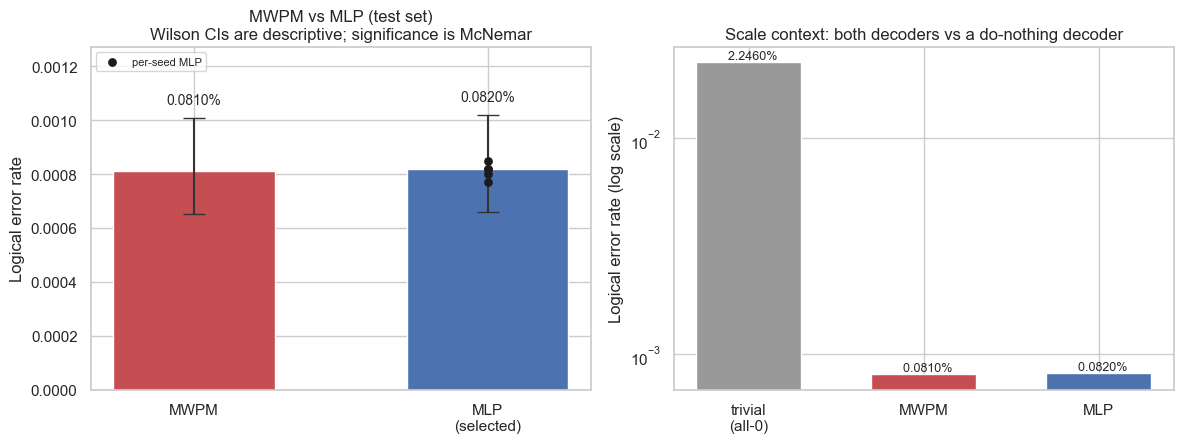

In [32]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.6))

# --- Left: the real comparison, linear axis, with DESCRIPTIVE Wilson CIs --------------
decoders = ['MWPM', 'MLP\n(selected)']
rates  = [mwpm_rate, mlp_rate]
yerr   = [[mwpm_rate - mwpm_lo, mlp_rate - mlp_lo],
          [mwpm_hi - mwpm_rate, mlp_hi - mlp_rate]]
colors = ['#C44E52', '#4C72B0']

bars = axL.bar(decoders, rates, color=colors, width=0.55,
               yerr=yerr, capsize=8, error_kw={'elinewidth': 1.5, 'ecolor': '#333333'})
# Per-seed MLP test LER as a point cloud over the MLP bar (training-init variance).
axL.scatter(np.full(len(seed_test_lers), 1.0), seed_test_lers,
            color='#1b1b1b', s=28, zorder=5, label='per-seed MLP')
axL.set_ylabel('Logical error rate')
axL.set_title('MWPM vs MLP (test set)\nWilson CIs are descriptive; significance is McNemar')
top = max(mwpm_hi, mlp_hi, seed_test_lers.max())
for bar, r, hi in zip(bars, rates, [mwpm_hi, mlp_hi]):
    axL.text(bar.get_x() + bar.get_width()/2, hi + top*0.04,
             f'{r:.4%}', ha='center', va='bottom', fontsize=10)
axL.set_ylim(0, top * 1.25)
axL.legend(loc='upper left', fontsize=8)

# --- Right: scale context, log axis, including the trivial baseline -------------------
ctx = ['trivial\n(all-0)', 'MWPM', 'MLP']
ctx_rates = [triv_ler, mwpm_ler, mlp_ler]
axR.bar(ctx, ctx_rates, color=['#999999', '#C44E52', '#4C72B0'], width=0.6)
axR.set_yscale('log')
axR.set_ylabel('Logical error rate (log scale)')
axR.set_title('Scale context: both decoders vs a do-nothing decoder')
for i, r in enumerate(ctx_rates):
    axR.text(i, r, f'  {r:.4%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Interpretation — Statistical Significance

Read the **printed verdict** above, not a number written in this cell. The logic behind it:

- The **paired difference** (MLP − MWPM LER) and its CI are the honest effect size. The CI is wide relative to the difference, because it is driven by the handful of discordant shots.
- **McNemar's p-value** is the significance test. At this sample size it is almost certainly *not* significant — and the verdict says so as **"no difference detected (underpowered),"** because the discordant count is too small for even a unanimous split to clear p < 0.05. A non-significant result here is the test admitting it cannot tell the decoders apart; it is **not** a proof that they are equal.

**The binding uncertainty is one we have not removed.** Three different sources of noise are in play, and only some are quantified:

1. *Binomial counting noise* on ~80 errors (the Wilson CIs) — descriptive.
2. *Training-init variance* across seeds (the point cloud) — descriptive.
3. *Test-set sampling variance*: this is a **single** 100,000-shot draw (Phase-2 seed 42). McNemar conditions on exactly these shots, and the multi-seed run only varies the model — so neither captures how the answer would move on a *different* 100k draw. With ~80 errors that draw-to-draw wobble is the dominant uncertainty, and the only real fix is **more logical-error events**: far more shots, or a higher physical error rate. That is exactly what the Iteration-2 threshold sweep provides.

Agreement breakdown (paired, same shots):
  Both correct      : 99,895
  Both wrong        : 58
  Only MWPM correct : 24   <- McNemar b
  Only MLP correct  : 23   <- McNemar c
  Agreement rate    : 99.9530%
  (McNemar uses ONLY b and c — the 47 discordant shots — not the marginal totals.)

MWPM errors = 81  (missed flips 40 + false alarms 41)
MLP  errors = 82  (missed flips 48 + false alarms 34)


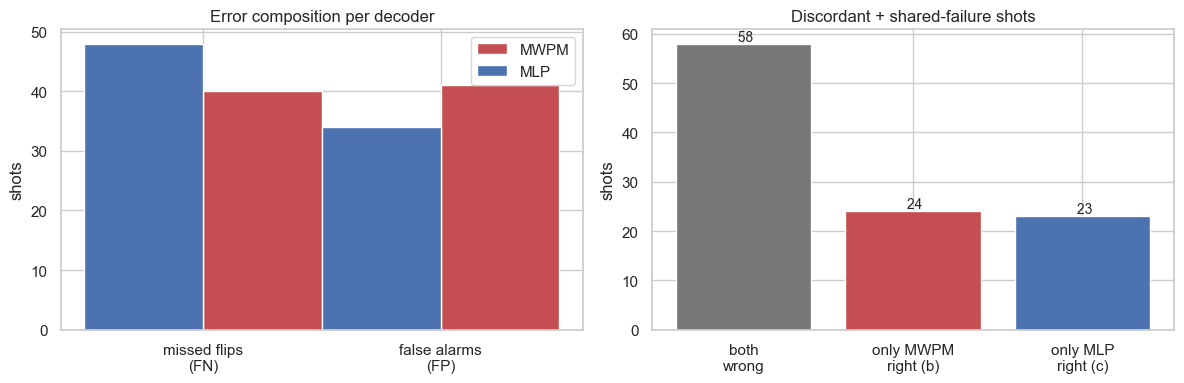

In [33]:
# 2x2 agreement breakdown (computed in 4.1: both_right, both_wrong, b, c)
print('Agreement breakdown (paired, same shots):')
print(f'  Both correct      : {both_right:,}')
print(f'  Both wrong        : {both_wrong:,}')
print(f'  Only MWPM correct : {mwpm_only_right:,}   <- McNemar b')
print(f'  Only MLP correct  : {mlp_only_right:,}   <- McNemar c')
print(f'  Agreement rate    : {(both_right + both_wrong) / n_test:.4%}')
print(f'  (McNemar uses ONLY b and c — the {n_discordant} discordant shots — not the marginal totals.)')

# Where does each decoder's error budget go? FN = missed a real flip; FP = false alarm.
def fp_fn(pred):
    fn = int(np.sum((pred == False) & (y_test == True)))   # missed flip
    fp = int(np.sum((pred == True)  & (y_test == False)))  # false alarm
    return fn, fp

mwpm_fn, mwpm_fp = fp_fn(mwpm_pred)
mlp_fn,  mlp_fp  = fp_fn(mlp_pred)
assert mwpm_fn + mwpm_fp == mwpm_errors and mlp_fn + mlp_fp == mlp_errors
print(f'\nMWPM errors = {mwpm_errors}  (missed flips {mwpm_fn} + false alarms {mwpm_fp})')
print(f'MLP  errors = {mlp_errors}  (missed flips {mlp_fn} + false alarms {mlp_fp})')

# Counts charts (COUNTS, not rates — these are integer events, not probabilities).
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.bar(['missed flips\n(FN)', 'false alarms\n(FP)'], [mwpm_fn, mwpm_fp],
       width=0.5, color='#C44E52', label='MWPM', align='edge')
a1.bar(['missed flips\n(FN)', 'false alarms\n(FP)'], [mlp_fn, mlp_fp],
       width=-0.5, color='#4C72B0', label='MLP', align='edge')
a1.set_ylabel('shots'); a1.set_title('Error composition per decoder'); a1.legend()

a2.bar(['both\nwrong', 'only MWPM\nright (b)', 'only MLP\nright (c)'],
       [both_wrong, b, c], color=['#777777', '#C44E52', '#4C72B0'])
a2.set_ylabel('shots'); a2.set_title('Discordant + shared-failure shots')
for i, v in enumerate([both_wrong, b, c]):
    a2.text(i, v, f' {v}', ha='center', va='bottom', fontsize=10)
plt.tight_layout(); plt.show()

### Interpretation — Agreement

The two decoders agree on virtually every shot; the breakdown tells the rest of the story.

The large **both-wrong** bucket is often described as "uncorrectable errors that no decoder could fix." That is **not quite right at d=3.** MWPM is a *minimum-weight* matcher: it picks the lowest-weight error chain consistent with the syndrome. But the most-likely *logical class* is not always the one reachable by the single lowest-weight chain — many distinct physical errors map to the same logical effect (**degeneracy**), and a maximum-likelihood decoder sums over them. So the both-wrong bucket is a **mix**: some shots are genuinely high-weight chains that cross the code (truly uncorrectable, fixable only by increasing the distance), but some are *degeneracy/min-weight mistakes* that a smarter (ML-style) decoder could recover. The true floor — the optimal decoder's failure rate — is therefore **strictly below** what these two particular decoders both miss.

The `only MWPM right (b)` and `only MLP right (c)` buckets are the shots where the *choice of decoder* mattered — and they are the *only* shots McNemar uses. They are tiny here, which is precisely why the comparison is underpowered. If the MLP had genuinely learned to exploit degeneracy, we would expect `c` to consistently exceed `b`; at d=3 the margin is small and a single run cannot resolve it. Iteration 2 (CNN at d=5, with far more error events) is where such a difference could actually be measured.

**What was done:**
- Loaded the Phase 2 stratified train/val/test splits (d=3, p=10⁻³, 1M shots), with asserts that lock the exact documented partition.
- Established the **MWPM baseline** with PyMatching, using a DEM built straight from the circuit (no labels) — a fair, learning-free reference.
- Trained an **MLP decoder** across **5 random seeds**, selecting models on smooth `val_loss` (not noisy `val_ler`), with early stopping.
- Compared the validation-selected MLP against MWPM on identical test shots using the correct **paired** statistics: a McNemar exact test, a paired-difference CI, and an explicit power floor — with a trivial-baseline for scale.

**Key result (read the printed verdict, not a hard-coded number):**
Both decoders sit far below the trivial "always-predict-0" baseline, confirming the neural pipeline genuinely decodes. The MLP's per-seed test LER lands in the same region as MWPM, but the two decoders disagree on only a few dozen of the 100,000 shots — too few for McNemar to reach significance. The honest reading is **"no difference detected at this sample size (underpowered),"** which is *not* the same as "the MLP equals MWPM." We make no claim of superiority or equivalence from this single test.

**Why we did not just say "the MLP matches MWPM":**
- At ~80 errors, the binomial counting noise (≈ ±9) already swamps any plausible MLP-vs-MWPM gap.
- The decoders' disagreement set is tiny, so the paired test is structurally underpowered (a unanimous split of ≤5 discordant shots cannot even reach p < 0.05).
- The deeper, unquantified uncertainty is **test-set sampling variance**: this is one 100k-shot draw, and neither McNemar (which conditions on these shots) nor the multi-seed spread (which varies only the model) captures how the result would move on a different draw.

**Methodological guardrails:**
- The selection rule (best `val_loss` → one McNemar test) was **pre-registered in markdown before any test-set cell**, so the test set still feeds exactly one reported comparison despite training 5 seeds. No threshold tuning (0.5 is Bayes-optimal under symmetric cost and would unfairly advantage the MLP).
- MWPM uses the circuit's DEM, never labels; both decoders are scored on the same shots; MWPM predictions were checked to be reproducible.

**A QEC correction worth keeping in mind:**
MWPM is *not* an unbeatable ceiling at d=3. Because it minimises matching weight rather than likelihood, it ignores **degeneracy**, so a maximum-likelihood (ML-style) decoder can beat it even at d=3 — by a small, hard-to-measure margin. The "both-wrong" shots are therefore a mix of genuinely uncorrectable high-weight chains and reducible min-weight mistakes, not a hard floor.

**Next — Iteration 2:**
1. Reshape syndromes into the 2D lattice and train a **CNN** at d=5.
2. Sweep physical error rate p to produce **logical-error-rate threshold curves**, with enough shots per point that McNemar is actually powered — this is where a neural-vs-MWPM difference, if real, becomes measurable.
3. Tune hyperparameters and analyse where (and whether) the neural decoder exploits degeneracy and correlated errors to beat MWPM.